In [11]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

In [13]:
I_points = [10,20,30,40,50]

stat_sim_log = {}
for P_des in [1.3,1.4,1.5]:
    for T_des in [323.15,333.15,343.15]:
        states_dyn = []
        states_stat = []
        print(f"Simulating for RHC={0.5}, P_des={P_des} bar, T_des={T_des} K...")
        for I_LOAD in I_points:
            # --------------- Steady-state Simulation  --------------- #
            operating_inputs_stat = operating_inputs.copy()
            Wout_c = 20 + I_LOAD * 1.
            Win_c = 10 + I_LOAD *1.8
            operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0.0, 'Phi_c_des': 0.5,
                                                    'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                    'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 4.8, 'Wout_a': 4.8}
            model = PEMFC_stat(parameters,operating_inputs_stat)
            sol = model.solve(I_LOAD/parameters['Aact'])
            # --------------- Log states for steady-state simulation  --------------- #
            states_stat.append(sol)
        
        # --------------- Log states for both simulations  --------------- #
        stat_sim_log["RHA"+str(0)+"/RHC" + str(0.5) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

Simulating for RHC=0.5, P_des=1.3 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=343.15 K...


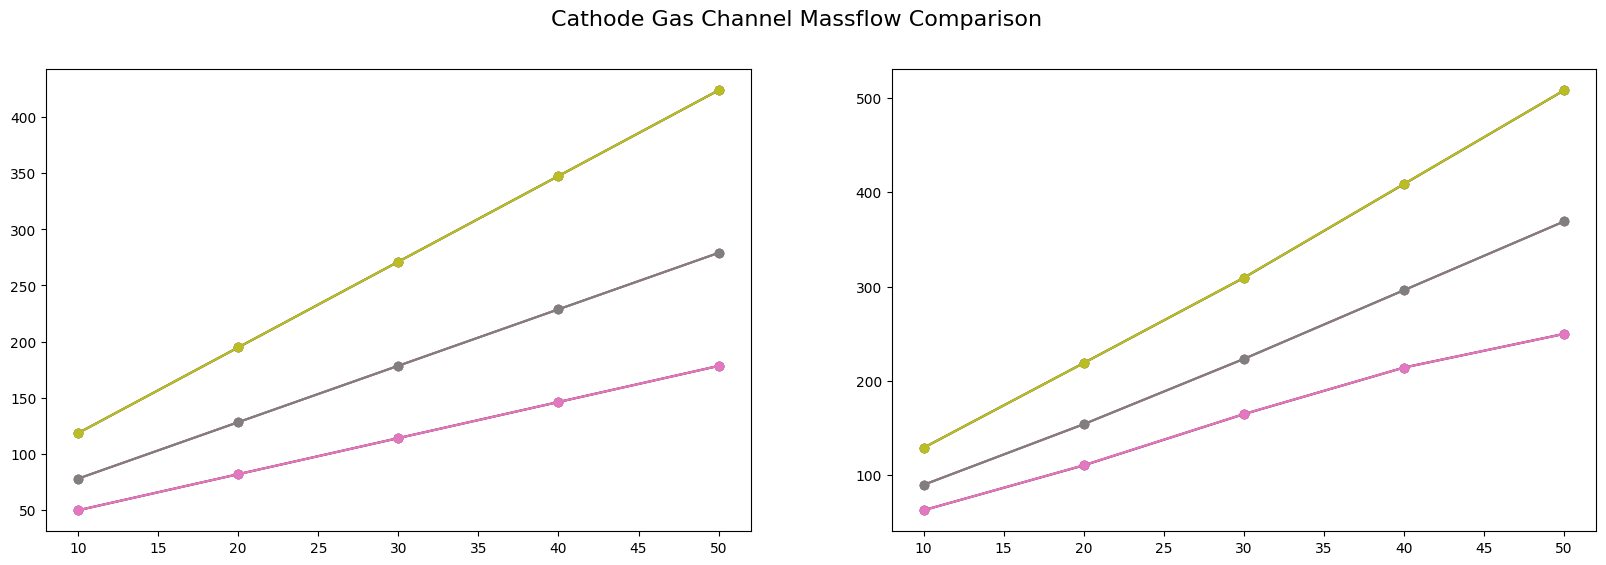

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)

# DEB_H2O [NL/min] → mol/(m³·s)
# NL/min → m³/s: ×1e-3/60 ; m³/s → mol/s: ÷Vm_STP ; mol/s → mol/(m³·s): ÷V_gc_total
Vm_STP = R * 273.15 / 101325  # m³/mol at standard conditions (0°C, 1 atm)
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]
conv_DEB_H2O = 1e-3 / 60 / Vm_STP / V_gc_total  # (mol/m³/s) per (NL/min)

for key in stat_sim_log.keys():
    states_stat = stat_sim_log[key]["states"]
    # Dynamic vs static model results
    axes[0].plot(I_points, [states["Jv_c_in"] for states in states_stat], label=key, marker='o')
    axes[1].plot(I_points, [states["Jv_c_out"] for states in states_stat], label=key, marker='o')

### Steady-State Results
- **$\lambda_{acl}$ / $\lambda_{ccl}$**: Water content at the anode / cathode catalyst layer
- **$C_{v,acl}$ / $C_{v,ccl}$**: Vapor concentration at the anode / cathode catalyst layer (mol/m³)
- **$J_{w,an}$ / $J_{w,ca}$**: Water flux in the anode / cathode GDL (mol/m²s)
- **$s_{agdl}$ / $s_{cgdl}$**: Saturation profile in the anode / cathode GDL, with vertical dashed lines at the saturation front ($x_{front}$)